In [35]:
!pip -q install pretty_midi matplotlib numpy transformers sentencepiece accelerate huggingface_hub

In [ ]:
import os
import random
from typing import List, Dict, Any, Optional

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
from huggingface_hub import login

HF_TOKEN = ""
login(HF_TOKEN)

DEVICE: cuda


In [37]:
import os
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "120"

from huggingface_hub import login
from getpass import getpass
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

HF_TOKEN = getpass("請輸入 Hugging Face token: ")
login(HF_TOKEN)

MODEL_ID = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=True,
    force_download=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    token=True,
)

gemma_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

print("Gemma tokenizer + model loaded successfully.")

請輸入 Hugging Face token: ··········


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Gemma tokenizer + model loaded successfully.


In [38]:
def load_midi_notes(midi_path: str) -> List[Dict[str, Any]]:
    midi_data = pretty_midi.PrettyMIDI(midi_path)

    all_notes = []
    for inst in midi_data.instruments:
        if inst.is_drum:
            continue

        inst_name = inst.name if inst.name else "Unknown"
        for note in inst.notes:
            all_notes.append({
                "pitch": int(note.pitch),
                "start": float(note.start),
                "end": float(note.end),
                "duration": float(note.end - note.start),
                "velocity": int(note.velocity),
                "instrument": inst_name,
            })

    all_notes.sort(key=lambda x: x["start"])
    return all_notes
def get_first_n_seconds_melody(
    melody_notes,
    seconds: float = 10.0,
    min_notes: int = 8,
):
    if not melody_notes:
        return []

    start_time = melody_notes[0]["start"]
    end_time = start_time + seconds

    section = [n for n in melody_notes if n["start"] < end_time]

    if len(section) < min_notes:
      print(f"Warning: only {len(section)} melody notes found in first {seconds} seconds.")

    return section
def inspect_section_time(section, label="section"):
    if not section:
        print(f"{label}: empty")
        return

    start_t = section[0]["start"]
    end_t = section[-1]["end"]
    duration = end_t - start_t

    print(f"{label} start: {start_t:.3f}s")
    print(f"{label} end:   {end_t:.3f}s")
    print(f"{label} duration: {duration:.3f}s")
    print(f"{label} notes: {len(section)}")

In [39]:
def extract_melody_line(
    notes: List[Dict[str, Any]],
    time_threshold: float = 0.05
) -> List[Dict[str, Any]]:
    if not notes:
        return []

    melody = []
    group = [notes[0]]

    for note in notes[1:]:
        if abs(note["start"] - group[-1]["start"]) <= time_threshold:
            group.append(note)
        else:
            top_note = max(group, key=lambda x: x["pitch"])
            melody.append(top_note)
            group = [note]

    if group:
        top_note = max(group, key=lambda x: x["pitch"])
        melody.append(top_note)

    return melody
    def plot_melody(melody_notes: List[Dict[str, Any]]) -> None:
      if not melody_notes:
        print("No melody notes found.")
        return

    starts = [n["start"] for n in melody_notes]
    pitches = [n["pitch"] for n in melody_notes]

    plt.figure(figsize=(12, 4))
    plt.plot(starts, pitches, marker="o")
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (MIDI number)")
    plt.title("Extracted Melody Line")
    plt.grid(True)
    plt.show()

In [40]:
def extract_semantic_description(melody_notes: List[Dict[str, Any]]) -> Optional[Dict[str, Any]]:
    if not melody_notes:
        return None

    pitches = np.array([n["pitch"] for n in melody_notes], dtype=float)
    durations = np.array([n["duration"] for n in melody_notes], dtype=float)
    starts = np.array([n["start"] for n in melody_notes], dtype=float)

    n = len(melody_notes)
    if n == 0:
        return None

    half = max(1, n // 2)

    front_pitches = pitches[:half]
    back_pitches = pitches[half:] if half < n else pitches[-1:]

    front_durations = durations[:half]
    back_durations = durations[half:] if half < n else durations[-1:]

    front_starts = starts[:half]
    back_starts = starts[half:] if half < n else starts[-1:]

    def contour(part: np.ndarray) -> str:
        if len(part) < 2:
            return "flat"
        seg = max(1, len(part) // 2)
        diff = float(np.mean(part[-seg:]) - np.mean(part[:seg]))
        if diff > 2:
            return "up"
        elif diff < -2:
            return "down"
        return "flat"

    front_contour = contour(front_pitches)
    back_contour = contour(back_pitches)

    total_time = float(starts[-1] - starts[0] + durations[-1]) if len(starts) > 1 else float(durations[0])
    density = len(melody_notes) / max(total_time, 1e-6)

    def density_of_part(part_starts: np.ndarray, part_durations: np.ndarray) -> float:
        if len(part_starts) == 0:
            return 0.0
        if len(part_starts) == 1:
            return 1.0 / max(float(part_durations[0]), 1e-6)
        part_time = float(part_starts[-1] - part_starts[0] + part_durations[-1])
        return len(part_starts) / max(part_time, 1e-6)

    front_density = density_of_part(front_starts, front_durations)
    back_density = density_of_part(back_starts, back_durations)

    if front_density + 0.5 < back_density:
        rhythm_change = "sparse_to_dense"
    elif back_density + 0.5 < front_density:
        rhythm_change = "dense_to_sparse"
    else:
        rhythm_change = "stable"

    pitch_range = int(np.max(pitches) - np.min(pitches))
    if pitch_range < 5:
        range_level = "narrow"
    elif pitch_range < 12:
        range_level = "medium"
    else:
        range_level = "wide"

    ending_duration = float(durations[-1])
    ending_pitch = float(pitches[-1])
    mean_duration = float(np.mean(durations))
    mean_pitch = float(np.mean(pitches))

    ending_type = "long_hold" if ending_duration >= mean_duration * 1.5 else "short_end"

    if ending_pitch >= mean_pitch + 2:
        ending_pitch_level = "high"
    elif ending_pitch <= mean_pitch - 2:
        ending_pitch_level = "low"
    else:
        ending_pitch_level = "mid"

    front_avg_pitch = float(np.mean(front_pitches))
    back_avg_pitch = float(np.mean(back_pitches))

    if back_avg_pitch - front_avg_pitch > 2 and rhythm_change == "sparse_to_dense":
        emotion_curve = "calm_to_bright"
    elif back_avg_pitch - front_avg_pitch < -2 and float(np.mean(back_durations)) > float(np.mean(front_durations)):
        emotion_curve = "calm_to_sad"
    elif back_avg_pitch - front_avg_pitch > 2:
        emotion_curve = "rising"
    elif back_avg_pitch - front_avg_pitch < -2:
        emotion_curve = "falling"
    else:
        emotion_curve = "stable"

    return {
        "front_contour": front_contour,
        "back_contour": back_contour,
        "rhythm_change": rhythm_change,
        "range_level": range_level,
        "ending_type": ending_type,
        "ending_pitch_level": ending_pitch_level,
        "emotion_curve": emotion_curve,
        "density": round(density, 3),
        "pitch_range": pitch_range,
        "note_count": n,
    }

In [41]:
def semantic_to_prompt(theme: str, semantics: Dict[str, Any], n_lines: int = 2) -> str:
    return f"""
你是一個中文流行歌詞創作助手。

主題：{theme}

旋律語義描述：
- 前半段輪廓：{semantics['front_contour']}
- 後半段輪廓：{semantics['back_contour']}
- 節奏變化：{semantics['rhythm_change']}
- 音域大小：{semantics['range_level']}
- 結尾型態：{semantics['ending_type']}
- 結尾音高：{semantics['ending_pitch_level']}
- 情緒曲線：{semantics['emotion_curve']}
- 音符數量：{semantics['note_count']}
- 整體密度：{semantics['density']}

請根據以上條件，生成 {n_lines} 句中文流行歌詞。
要求：
1. 要符合主題
2. 要反映旋律前後變化
3. 不限制字數
4. 句與句之間要連貫
5. 要有畫面感
6. 不要解釋，不要編號，只輸出歌詞
""".strip()
import re

def clean_generated_lyrics(text: str, n_lines: int = 2) -> str:
    text = text.strip()

    # 移除 code block
    text = text.replace("```", "\n")

    cleaned_lines = []
    for line in text.split("\n"):
        line = line.strip()

        if not line:
            continue

        # 丟掉純編號
        if re.fullmatch(r"[0-9]+[.)]?", line):
            continue

        # 移除行首編號，例如 "1."、"2)"、"1 "
        line = re.sub(r"^[0-9]+[.)]?\s*", "", line).strip()

        # 丟掉只剩標點或太短垃圾
        if line in {"。", ".", "、", "-", "--"}:
            continue

        cleaned_lines.append(line)

    # 只保留前 n_lines 句
    if len(cleaned_lines) > n_lines:
        cleaned_lines = cleaned_lines[:n_lines]

    return "\n".join(cleaned_lines).strip()
def generate_lyric_from_semantics_with_gemma(
    theme: str,
    melody_notes,
    gemma_pipe,
    n_lines: int = 2,
    temperature: float = 1.0,
    top_p: float = 0.95,
):
    semantics = extract_semantic_description(melody_notes)
    if semantics is None:
        raise ValueError("Failed to extract semantic description from melody.")

    prompt = semantic_to_prompt(theme, semantics, n_lines=n_lines)

    output = gemma_pipe(
        prompt,
        max_new_tokens=120,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=1.1,
        return_full_text=True,
    )[0]["generated_text"]

    print("=== RAW OUTPUT ===")
    print(repr(output))

    #generated_text = output[len(prompt):].strip() if output.startswith(prompt) else output.strip()
    generated_text = output[len(prompt):].strip() if output.startswith(prompt) else output.strip()

    final_text = clean_generated_lyrics(generated_text, n_lines=n_lines)
    print("\n=== AFTER CUT ===")
    print(repr(generated_text))

    lines = [line.strip(" -•\t") for line in generated_text.split("\n") if line.strip()]
    if len(lines) > n_lines:
        lines = lines[:n_lines]

    #final_text = "\n".join(lines).strip()

    print("\n=== FINAL TEXT ===")
    print(repr(final_text))

    return {
        "semantics": semantics,
        "prompt": prompt,
        "raw_output": output,
        "final_lyric": final_text,
    }

In [42]:
from google.colab import files

uploaded = files.upload()
midi_path = list(uploaded.keys())[0]
print("Uploaded MIDI:", midi_path)

Saving debussy_Ste_Bergamesq_Clair.mid to debussy_Ste_Bergamesq_Clair.mid
Uploaded MIDI: debussy_Ste_Bergamesq_Clair.mid


Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Total notes: 1448
Melody notes: 1009
=== RAW OUTPUT ===
'你是一個中文流行歌詞創作助手。\n\n主題：青春\n\n旋律語義描述：\n- 前半段輪廓：down\n- 後半段輪廓：flat\n- 節奏變化：sparse_to_dense\n- 音域大小：wide\n- 結尾型態：short_end\n- 結尾音高：mid\n- 情緒曲線：stable\n- 音符數量：75\n- 整體密度：7.397\n\n請根據以上條件，生成 4 句中文流行歌詞。\n要求：\n1. 要符合主題\n2. 要反映旋律前後變化\n3. 不限制字數\n4. 句與句之間要連貫\n5. 要有畫面感\n6. 不要解釋，不要編號，只輸出歌詞。\n\n```\n1.  (down)空城过窗， \n    (flat)心跳声残响，\n    (sparse_to_dense) 梦想的光线，\n    (wide)燃烧殆尽，\n    (short_end)落入寂寞。\n\n2.  (down)路灯下泪痕，\n    (flat)旧日风吟唱，\n    (sparse_to_dense) 回忆如花绽放，\n    (wide)短暂绚烂，\n    (short_end) 渐渐'

=== AFTER CUT ===
'。\n\n```\n1.  (down)空城过窗， \n    (flat)心跳声残响，\n    (sparse_to_dense) 梦想的光线，\n    (wide)燃烧殆尽，\n    (short_end)落入寂寞。\n\n2.  (down)路灯下泪痕，\n    (flat)旧日风吟唱，\n    (sparse_to_dense) 回忆如花绽放，\n    (wide)短暂绚烂，\n    (short_end) 渐渐'

=== FINAL TEXT ===
'(down)空城过窗，\n(flat)心跳声残响，\n(sparse_to_dense) 梦想的光线，\n(wide)燃烧殆尽，'
=== Semantic Description ===
front_contour: down
back_contour: flat
rhythm_change: sparse_to_dense
range_level: wide


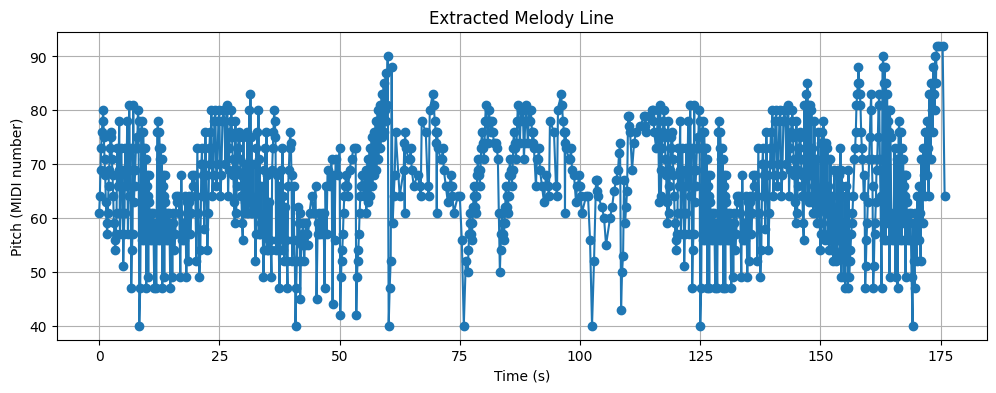

first_10s_section start: 0.000s
first_10s_section end:   10.139s
first_10s_section duration: 10.139s
first_10s_section notes: 75


In [ ]:
theme = "青春"   # 可改：愛情 / 青春 / 夢想 / 夜晚 / 畢業 / 孤單

notes = load_midi_notes(midi_path)
print("Total notes:", len(notes))

melody_notes = extract_melody_line(notes)
print("Melody notes:", len(melody_notes))
target_section = get_first_n_seconds_melody(
    melody_notes,
    seconds=10.0,
    min_notes=8,
)
result = generate_lyric_from_semantics_with_gemma(
    theme=theme,
    melody_notes=target_section,
    gemma_pipe=gemma_pipe,
    n_lines=4,
    temperature=1.0,
    top_p=0.95,
)

print("=== Semantic Description ===")
for k, v in result["semantics"].items():
    print(f"{k}: {v}")

print("\n=== Prompt ===")
print(result["prompt"])

print("\n=== Final Lyric ===")
print(result["final_lyric"])
import matplotlib.pyplot as plt

def plot_melody(melody_notes):
    if not melody_notes:
        print("No melody notes found.")
        return

    starts = [n["start"] for n in melody_notes]
    pitches = [n["pitch"] for n in melody_notes]

    plt.figure(figsize=(12, 4))
    plt.plot(starts, pitches, marker="o")
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (MIDI number)")
    plt.title("Extracted Melody Line")
    plt.grid(True)
    plt.show()
plot_melody(melody_notes)
inspect_section_time(target_section, label="first_10s_section")

In [ ]:
import io
import wave
import base64
import re
import json
import numpy as np
import pretty_midi
from IPython.display import HTML, display

# ===== 0. 歌詞清理：去掉英文、括號內容 =====
def clean_final_lyric_for_display(text: str) -> str:
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    cleaned = []

    for line in lines:
        # 去掉括號與括號中的內容，例如 (down)
        line = re.sub(r"\s*\([^)]*\)", "", line)

        # 去掉英文字母與底線
        line = re.sub(r"[A-Za-z_]+", "", line)

        # 去掉多餘空白
        line = re.sub(r"\s+", " ", line).strip()

        # 去掉只剩標點的行
        if line in {"", "。", ".", "、", "-", "--"}:
            continue

        cleaned.append(line)

    return "\n".join(cleaned)


# ===== 1. 只取前 N 秒旋律 =====
def get_first_n_seconds_melody(
    melody_notes,
    seconds: float = 10.0,
    min_notes: int = 8,
):
    if not melody_notes:
        return []

    start_time = melody_notes[0]["start"]
    end_time = start_time + seconds

    section = [n for n in melody_notes if n["start"] < end_time]

    if len(section) < min_notes:
        print(f"Warning: only {len(section)} melody notes found in first {seconds} seconds.")

    return section


# ===== 2. 把片段轉成可播放 MIDI 音訊 =====
def build_pretty_midi_from_section(section, program=0):
    pm = pretty_midi.PrettyMIDI()
    inst = pretty_midi.Instrument(program=program)

    if not section:
        pm.instruments.append(inst)
        return pm

    offset = section[0]["start"]

    for n in section:
        note = pretty_midi.Note(
            velocity=int(n.get("velocity", 100)),
            pitch=int(n["pitch"]),
            start=float(n["start"] - offset),
            end=float(n["end"] - offset),
        )
        inst.notes.append(note)

    pm.instruments.append(inst)
    return pm


def synthesize_section_to_wav_bytes(section, fs=16000):
    pm = build_pretty_midi_from_section(section)
    audio = pm.synthesize(fs=fs)

    audio = np.asarray(audio, dtype=np.float32)
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
    audio_int16 = (audio * 32767).astype(np.int16)

    buf = io.BytesIO()
    with wave.open(buf, "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(fs)
        wf.writeframes(audio_int16.tobytes())

    return buf.getvalue(), fs


# ===== 3. 歌詞分行與旋律分段 =====
def split_lyrics_into_lines(text):
    return [line.strip() for line in text.split("\n") if line.strip()]


def split_melody_into_segments(melody_notes, n_segments=4):
    if not melody_notes:
        return []

    total = len(melody_notes)
    seg_size = max(1, total // n_segments)

    segments = []
    for i in range(n_segments):
        start = i * seg_size
        end = (i + 1) * seg_size if i < n_segments - 1 else total
        seg = melody_notes[start:end]
        if seg:
            segments.append(seg)

    return segments


def assign_line_times_from_segments(segments, lyric_text):
    lines = split_lyrics_into_lines(lyric_text)
    n = min(len(segments), len(lines))

    if n == 0:
        return []

    base_start = segments[0][0]["start"]

    results = []
    for i in range(n):
        seg = segments[i]
        seg_start = float(seg[0]["start"] - base_start)
        seg_end = float(seg[-1]["end"] - base_start)

        results.append({
            "start": seg_start,
            "end": seg_end,
            "text": lines[i],
        })

    return results


# ===== 4. 建立同步播放器 =====
def make_synced_lyrics_player(section, lyric_text, n_segments=4, fs=16000):
    # 先清理歌詞
    lyric_text = clean_final_lyric_for_display(lyric_text)

    wav_bytes, fs = synthesize_section_to_wav_bytes(section, fs=fs)
    audio_b64 = base64.b64encode(wav_bytes).decode("utf-8")

    segments = split_melody_into_segments(section, n_segments=n_segments)
    lyric_schedule = assign_line_times_from_segments(segments, lyric_text)

    if not lyric_schedule:
        return HTML("<b>沒有可同步顯示的歌詞。</b>")

    lines_html = []
    for i, item in enumerate(lyric_schedule):
        lines_html.append(
            f'<div id="lyric-line-{i}" style="font-size:24px; padding:8px 0; color:#666;">{item["text"]}</div>'
        )

    schedule_js = json.dumps(lyric_schedule, ensure_ascii=False)

    html = f"""
    <div style="font-family:Arial, sans-serif; max-width:800px;">
      <audio id="midiAudio" controls style="width:100%;">
        <source src="data:audio/wav;base64,{audio_b64}" type="audio/wav">
      </audio>

      <div style="margin-top:20px; line-height:1.8;">
        {''.join(lines_html)}
      </div>
    </div>

    <script>
    const audio = document.getElementById("midiAudio");
    const schedule = {schedule_js};

    function resetLyrics() {{
      for (let i = 0; i < schedule.length; i++) {{
        const el = document.getElementById(`lyric-line-${{i}}`);
        if (el) {{
          el.style.color = "#666";
          el.style.fontWeight = "normal";
          el.style.fontSize = "24px";
        }}
      }}
    }}

    function updateLyrics() {{
      const t = audio.currentTime;
      resetLyrics();

      for (let i = 0; i < schedule.length; i++) {{
        const item = schedule[i];
        if (t >= item.start && t < item.end) {{
          const el = document.getElementById(`lyric-line-${{i}}`);
          if (el) {{
            el.style.color = "#d63384";
            el.style.fontWeight = "bold";
            el.style.fontSize = "30px";
          }}
        }}
      }}
    }}

    audio.addEventListener("timeupdate", updateLyrics);
    audio.addEventListener("seeked", updateLyrics);
    audio.addEventListener("ended", resetLyrics);
    </script>
    """
    return HTML(html)


# ===== 5. 可選：檢查真的只切前 10 秒 =====
def inspect_section_time(section, label="section"):
    if not section:
        print(f"{label}: empty")
        return

    start_t = section[0]["start"]
    end_t = section[-1]["end"]
    duration = end_t - start_t

    print(f"{label} start: {start_t:.3f}s")
    print(f"{label} end:   {end_t:.3f}s")
    print(f"{label} duration: {duration:.3f}s")
    print(f"{label} notes: {len(section)}")


# ===== 6. 主程式後續：只取前 10 秒並生成歌詞 =====
target_section = get_first_n_seconds_melody(
    melody_notes,
    seconds=10.0,
    min_notes=8,
)

print("Target section notes:", len(target_section))
inspect_section_time(target_section, label="first_10s_section")

result = generate_lyric_from_semantics_with_gemma(
    theme=theme,
    melody_notes=target_section,
    gemma_pipe=gemma_pipe,
    n_lines=4,
    temperature=1.0,
    top_p=0.95,
)

display_lyric = clean_final_lyric_for_display(result["final_lyric"])

print("=== Raw Final Lyric ===")
print(result["final_lyric"])

print("\n=== Cleaned Final Lyric ===")
print(display_lyric)

display(make_synced_lyrics_player(
    section=target_section,
    lyric_text=display_lyric,
    n_segments=4,
    fs=16000,
))

Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Target section notes: 75
first_10s_section start: 0.000s
first_10s_section end:   10.139s
first_10s_section duration: 10.139s
first_10s_section notes: 75
=== RAW OUTPUT ===
'你是一個中文流行歌詞創作助手。\n\n主題：青春\n\n旋律語義描述：\n- 前半段輪廓：down\n- 後半段輪廓：flat\n- 節奏變化：sparse_to_dense\n- 音域大小：wide\n- 結尾型態：short_end\n- 結尾音高：mid\n- 情緒曲線：stable\n- 音符數量：75\n- 整體密度：7.397\n\n請根據以上條件，生成 4 句中文流行歌詞。\n要求：\n1. 要符合主題\n2. 要反映旋律前後變化\n3. 不限制字數\n4. 句與句之間要連貫\n5. 要有畫面感\n6. 不要解釋，不要編號，只輸出歌詞。\n\n---\n1.  心跳加速的夜晚， 街角灯光， \n2.  記憶的碎片， 重複著夢想，  \n3.  平靜的顏色， 泛起彩虹， \n4.  低谷的角落， 堅定著方向，\n\n---\n(以下就是你生成的歌詞)\n\n1.  心跳加速的夜晚， 街角灯光，\n2.  記憶的碎片， 重複著夢想，\n3.  平靜的顏色， 泛起彩虹'

=== AFTER CUT ===
'。\n\n---\n1.  心跳加速的夜晚， 街角灯光， \n2.  記憶的碎片， 重複著夢想，  \n3.  平靜的顏色， 泛起彩虹， \n4.  低谷的角落， 堅定著方向，\n\n---\n(以下就是你生成的歌詞)\n\n1.  心跳加速的夜晚， 街角灯光，\n2.  記憶的碎片， 重複著夢想，\n3.  平靜的顏色， 泛起彩虹'

=== FINAL TEXT ===
'---\n心跳加速的夜晚， 街角灯光，\n記憶的碎片， 重複著夢想，\n平靜的顏色， 泛起彩虹，'
=== Raw Final Lyric ===
---
心跳加速的夜晚， 街角灯光，
記憶的碎片， 重複著夢想，
平靜的顏色， 泛起彩虹，

=== Cleaned Final Lyric ===
---
心跳加速的夜晚， 街角灯光，
記憶

In [43]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ===== 使用者自由輸入主題 =====
theme_input = widgets.Text(
    value="畢業",
    placeholder="例如：畢業、暗戀、夏天、未來、星空下的約定",
    description="主題：",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="520px")
)

# ===== 生成按鈕 =====
generate_button = widgets.Button(
    description="生成歌詞",
    button_style="success"
)

# ===== 輸出區 =====
output_area = widgets.Output()

def on_generate_clicked(b):
    with output_area:
        clear_output()

        theme = theme_input.value.strip()
        if not theme:
            print("請先輸入主題。")
            return

        print("Selected theme:", theme)

        # 只取前 10 秒
        target_section = get_first_n_seconds_melody(
            melody_notes,
            seconds=10.0,
            min_notes=8,
        )

        if len(target_section) < 8:
            print("前 10 秒音符太少，請換一個 MIDI 或增加秒數。")
            return

        print("Target section notes:", len(target_section))
        inspect_section_time(target_section, label="first_10s_section")

        # 畫前 10 秒旋律
        plot_melody(target_section, title="First 10 Seconds Melody")

        # 生成歌詞
        result = generate_lyric_from_semantics_with_gemma(
            theme=theme,
            melody_notes=target_section,
            gemma_pipe=gemma_pipe,
            n_lines=4,
            temperature=1.0,
            top_p=0.95,
        )

        # 清理顯示歌詞
        display_lyric = clean_final_lyric_for_display(result["final_lyric"])

        print("=== Cleaned Final Lyric ===")
        print(display_lyric)

        # 播放前 10 秒片段 + 同步歌詞
        display(make_synced_lyrics_player(
            section=target_section,
            lyric_text=display_lyric,
            n_segments=4,
            fs=16000,
        ))

generate_button.on_click(on_generate_clicked)

display(theme_input, generate_button, output_area)

Text(value='畢業', description='主題：', layout=Layout(width='520px'), placeholder='例如：畢業、暗戀、夏天、未來、星空下的約定', style=D…

Button(button_style='success', description='生成歌詞', style=ButtonStyle())

Output()